# Meeting Prep: Product-Balanced Initializers Comparison

Multi-depth comparison of 4 initializers:
- **He** (baseline)
- **RC fwd-balanced** ($g_{\text{fwd}} = 1$, $g_{\text{bwd}} \approx 1.21$)
- **RC product-balanced (V1)** ($g_{\text{fwd}} \cdot g_{\text{bwd}} = 1$, uniform variance)
- **RC layer-balanced product-base (V2)** (per-layer $\eta$-schedule on product base)

Metrics: forward/backward gain, gain product, gradient norms, k-NN geometry.
Depths: $L \in \{10, 20, 50\}$.

In [1]:
# Setup
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import torch
import math
from collections import defaultdict

from rp_study.config import ExperimentConfig, NetworkConfig, GradientExperimentConfig
from rp_study.experiments.gradient_analysis import GradientExperiment, ExperimentResults
from rp_study.data.loaders import get_data_loader
from rp_study.projections import multi_layer_rp_with_init
from rp_study.analysis.geometry_metrics import evaluate_geometry
from rp_study.models.initializers import list_initializers

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Available initializers: {list_initializers()}')

Device: cpu
Available initializers: ['he', 'row_centered_he', 'row_centered_he_var_adj', 'partial_centered_he', 'orthogonal_he', 'orthogonal_tuned', 'centered_with_dc_he', 'custom_variance', 'xavier', 'uniform_he', 'orthogonal', 'kernel_preserving', 'angle_preserving', 'row_centered_final', 'row_centered_layer_balanced', 'row_centered_layer_balanced_he_base', 'row_centered_forward_balanced', 'row_centered_product_balanced', 'row_centered_layer_balanced_product_base']


In [2]:
# ====== CONFIGURATION ======

SEED = 42
DATASET = 'fashion_mnist'
DATA_DIR = '../data'
NUM_SAMPLES = 2000

_DATASET_INPUT_DIMS = {'mnist': 784, 'fashion_mnist': 784, 'cifar10': 3072}
INPUT_DIM = _DATASET_INPUT_DIMS[DATASET]

# Depths to compare
DEPTHS = [10, 20, 50]

# The 4 initializers
INIT_STRATEGIES = [
    'he',
    'row_centered_forward_balanced',
    'row_centered_product_balanced',
    'row_centered_layer_balanced_product_base',
]

INIT_LABELS = {
    'he': 'He (baseline)',
    'row_centered_forward_balanced': 'RC fwd-balanced',
    'row_centered_product_balanced': 'RC product-balanced (V1)',
    'row_centered_layer_balanced_product_base': 'RC layer-bal (V2, \u03b7=0.5)',
}

INIT_COLORS = {
    'he': 'tab:blue',
    'row_centered_forward_balanced': 'tab:red',
    'row_centered_product_balanced': 'tab:purple',
    'row_centered_layer_balanced_product_base': 'tab:green',
}

# Layer-balanced eta (V2)
LB_ETA = 0.5

# Output directory
FIGDIR = '../reports/latex/product_balanced_report/figures'

print(f'Dataset: {DATASET} (input_dim={INPUT_DIM})')
print(f'Depths: {DEPTHS}')
print(f'Initializers: {list(INIT_LABELS.values())}')

Dataset: fashion_mnist (input_dim=784)
Depths: [10, 20, 50]
Initializers: ['He (baseline)', 'RC fwd-balanced', 'RC product-balanced (V1)', 'RC layer-bal (V2, η=0.5)']


## Section 1: Gradient Diagnostics at Multiple Depths

Run gradient experiments for all 4 initializers at L = 10, 20, 50.

In [3]:
# Run gradient experiments for all (init, depth) combinations
grad_results = {}  # (init_strategy, depth) -> ExperimentResults

for depth in DEPTHS:
    WIDTH = INPUT_DIM
    LAYER_SIZES = [INPUT_DIM] + [WIDTH] * depth + [1]
    
    for init in INIT_STRATEGIES:
        label = INIT_LABELS[init]
        print(f'  L={depth}, {label}...', end=' ')
        
        exp_config = ExperimentConfig(seed=SEED, data_dir=DATA_DIR)
        exp_config.setup_seeds()
        grad_config = GradientExperimentConfig(num_samples=NUM_SAMPLES, dataset=DATASET)
        
        init_kwargs = {}
        if init == 'row_centered_layer_balanced_product_base':
            init_kwargs = {'eta': LB_ETA}
        
        net_config = NetworkConfig(
            layer_sizes=LAYER_SIZES,
            init_strategy=init,
            init_kwargs=init_kwargs,
        )
        exp = GradientExperiment(exp_config, net_config, grad_config)
        result = exp.run()
        grad_results[(init, depth)] = result
        
        # Summary stats
        fwd = list(result.get_forward_gains().values())
        bwd = list(result.get_backward_gains().values())
        norms = list(result.get_mean_row_norms().values())
        grad_ratio = max(norms) / max(min(norms), 1e-30)
        print(f'med_fwd={np.median(fwd):.3f}, med_bwd={np.median(bwd):.3f}, '
              f'grad_ratio={grad_ratio:.1f}x')

print('\nAll gradient experiments done!')

  L=10, He (baseline)... 

/Users/itayofer/Thesis/Thesis/notebooks/../src/rp_study/experiments/gradient_analysis.py:290: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


med_fwd=0.992, med_bwd=1.007, grad_ratio=121.1x
  L=10, RC fwd-balanced... 

med_fwd=0.992, med_bwd=1.209, grad_ratio=55.5x
  L=10, RC product-balanced (V1)... 

med_fwd=0.901, med_bwd=1.099, grad_ratio=55.5x
  L=10, RC layer-bal (V2, η=0.5)... 

...

med_fwd=0.959, med_bwd=1.051, grad_ratio=189.3x
  L=50, He (baseline)... 

med_fwd=0.992, med_bwd=0.997, grad_ratio=374.2x
  L=50, RC fwd-balanced... 

med_fwd=1.000, med_bwd=1.209, grad_ratio=1901.5x
  L=50, RC product-balanced (V1)... 

med_fwd=0.909, med_bwd=1.099, grad_ratio=1901.6x
  L=50, RC layer-bal (V2, η=0.5)... 

med_fwd=0.956, med_bwd=1.049, grad_ratio=191.8x

All gradient experiments done!


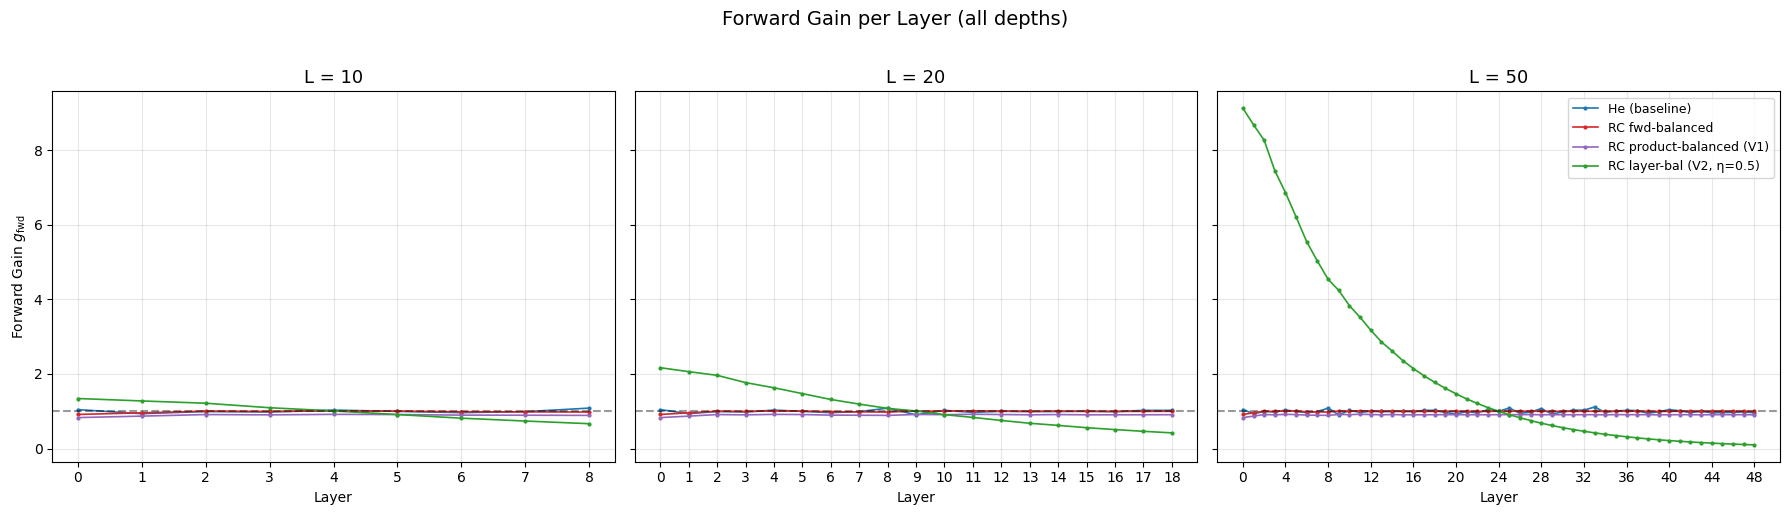

In [4]:
# ====== PLOT 1: Forward Gain per Layer (3-panel: L=10, 20, 50) ======

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, depth in zip(axes, DEPTHS):
    for init in INIT_STRATEGIES:
        label = INIT_LABELS[init]
        color = INIT_COLORS[init]
        result = grad_results[(init, depth)]
        gains = result.get_forward_gains()
        layers = list(gains.keys())
        if len(layers) > 1:
            layers = layers[:-1]  # exclude boundary
        vals = [gains[k] for k in layers]
        x = range(len(vals))
        ax.plot(x, vals, 'o-', markersize=2, label=label, color=color, linewidth=1.2)
    
    ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.4)
    ax.set_title(f'L = {depth}', fontsize=13)
    ax.set_xlabel('Layer')
    ax.grid(True, alpha=0.3)
    # Sparse ticks
    n_ticks = min(10, len(vals))
    step = max(1, len(vals) // n_ticks)
    ax.set_xticks(range(0, len(vals), step))

axes[0].set_ylabel('Forward Gain $g_{\\mathrm{fwd}}$')
axes[2].legend(loc='best', fontsize=9)
fig.suptitle('Forward Gain per Layer (all depths)', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/forward_gain_multi_depth.png', dpi=150, bbox_inches='tight')
plt.show()

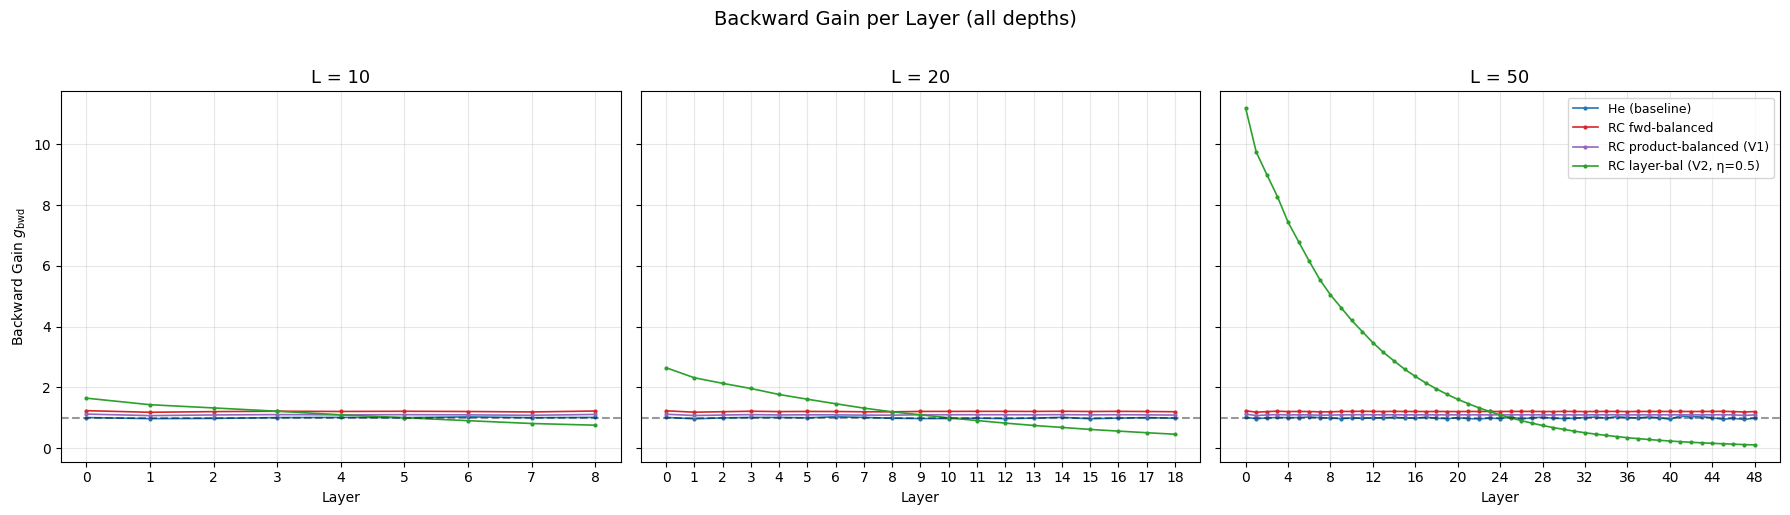

In [5]:
# ====== PLOT 2: Backward Gain per Layer (3-panel) ======

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, depth in zip(axes, DEPTHS):
    for init in INIT_STRATEGIES:
        label = INIT_LABELS[init]
        color = INIT_COLORS[init]
        result = grad_results[(init, depth)]
        gains = result.get_backward_gains()
        layers = list(gains.keys())
        if len(layers) > 1:
            layers = layers[:-1]
        vals = [gains[k] for k in layers]
        x = range(len(vals))
        ax.plot(x, vals, 'o-', markersize=2, label=label, color=color, linewidth=1.2)
    
    ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.4)
    ax.set_title(f'L = {depth}', fontsize=13)
    ax.set_xlabel('Layer')
    ax.grid(True, alpha=0.3)
    n_ticks = min(10, len(vals))
    step = max(1, len(vals) // n_ticks)
    ax.set_xticks(range(0, len(vals), step))

axes[0].set_ylabel('Backward Gain $g_{\\mathrm{bwd}}$')
axes[2].legend(loc='best', fontsize=9)
fig.suptitle('Backward Gain per Layer (all depths)', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/backward_gain_multi_depth.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/nk/_07pl3nj3n319q7_d1_096k80000gn/T/ipykernel_52243/1071328576.py:41: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/nk/_07pl3nj3n319q7_d1_096k80000gn/T/ipykernel_52243/1071328576.py:42: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.savefig(f'{FIGDIR}/gain_product_multi_depth.png', dpi=150, bbox_inches='tight')


/Users/itayofer/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


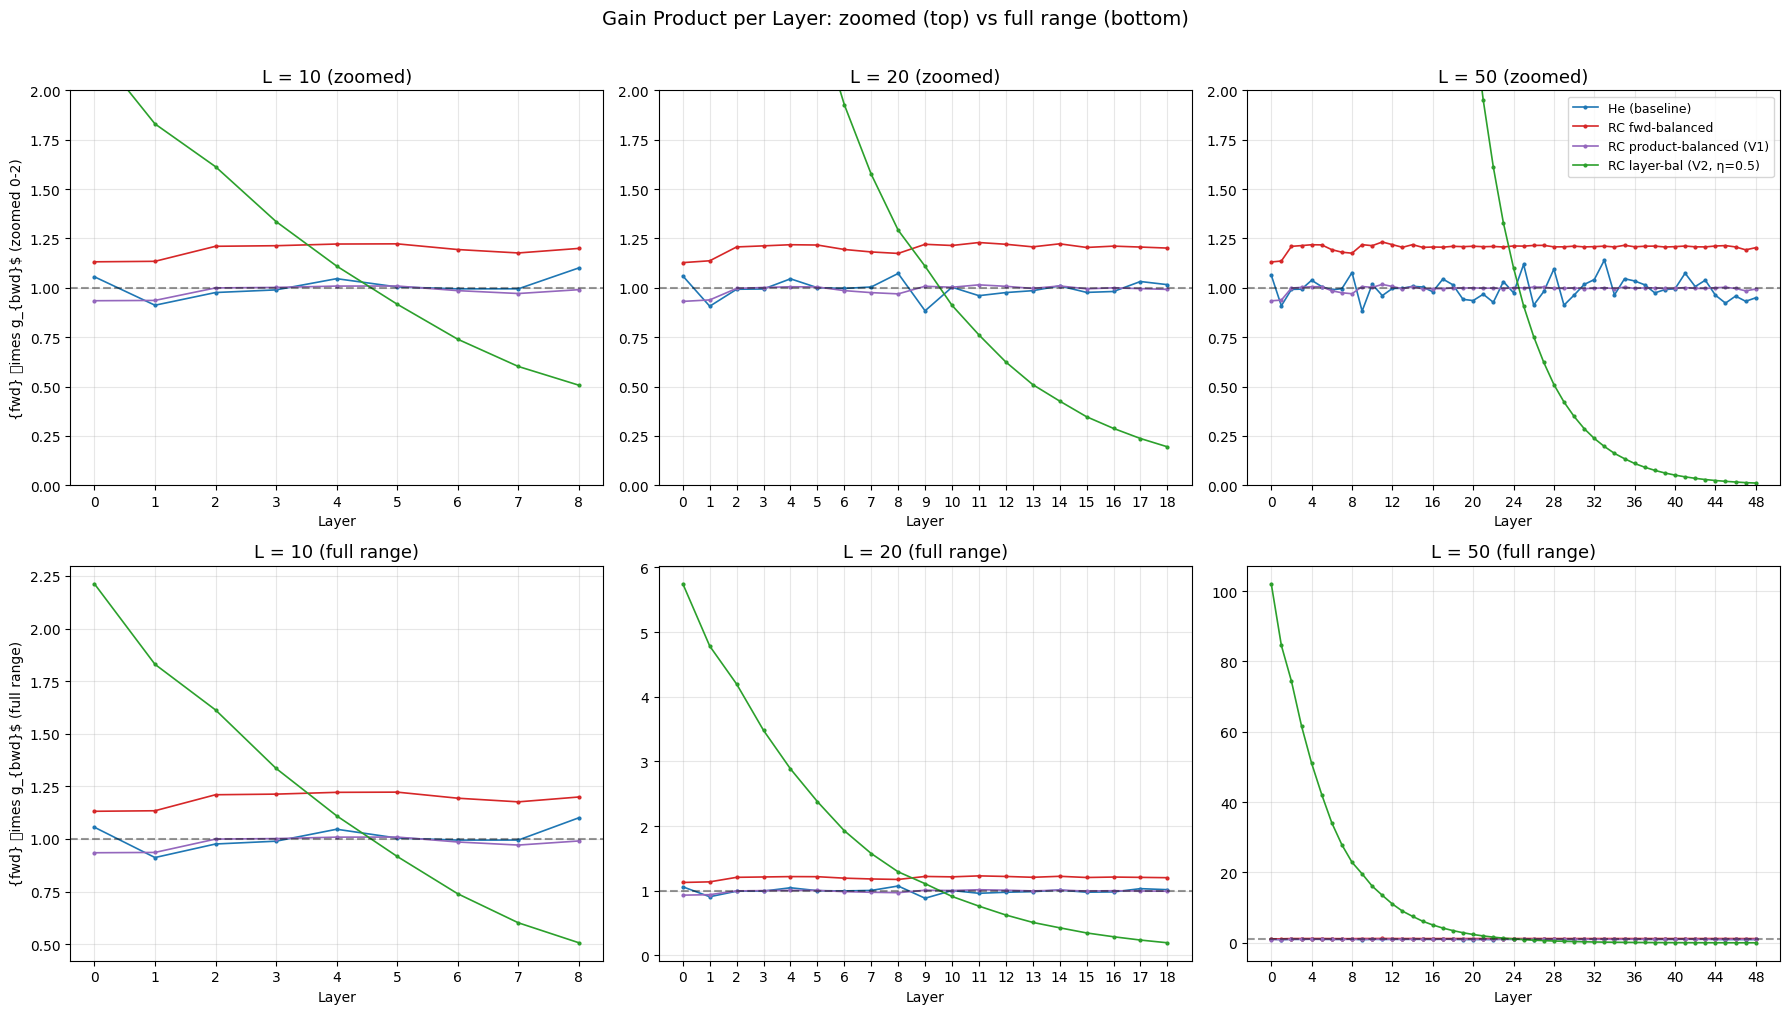

In [6]:
# ====== PLOT 3: Gain Product per Layer ======
# Top row: zoomed (0-2) to see V1/He/fwd-balanced clearly
# Bottom row: full range to show V2's per-layer product variation

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row in range(2):
    for col, depth in enumerate(DEPTHS):
        ax = axes[row][col]
        for init in INIT_STRATEGIES:
            label = INIT_LABELS[init]
            color = INIT_COLORS[init]
            result = grad_results[(init, depth)]
            fwd = result.get_forward_gains()
            bwd = result.get_backward_gains()
            layers = list(fwd.keys())
            if len(layers) > 1:
                layers = layers[:-1]
            products = [fwd[k] * bwd[k] for k in layers]
            x = range(len(products))
            ax.plot(x, products, 'o-', markersize=2, label=label, color=color, linewidth=1.2)
        
        ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.4)
        ax.set_xlabel('Layer')
        ax.grid(True, alpha=0.3)
        n_ticks = min(10, len(products))
        step = max(1, len(products) // n_ticks)
        ax.set_xticks(range(0, len(products), step))
        
        if row == 0:
            ax.set_ylim([0, 2.0])
            ax.set_title(f'L = {depth} (zoomed)', fontsize=13)
        else:
            ax.set_title(f'L = {depth} (full range)', fontsize=13)

axes[0][0].set_ylabel('{fwd} \times g_{bwd}$ (zoomed 0-2)')
axes[1][0].set_ylabel('{fwd} \times g_{bwd}$ (full range)')
axes[0][2].legend(loc='best', fontsize=9)

fig.suptitle('Gain Product per Layer: zoomed (top) vs full range (bottom)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/gain_product_multi_depth.png', dpi=150, bbox_inches='tight')
plt.show()


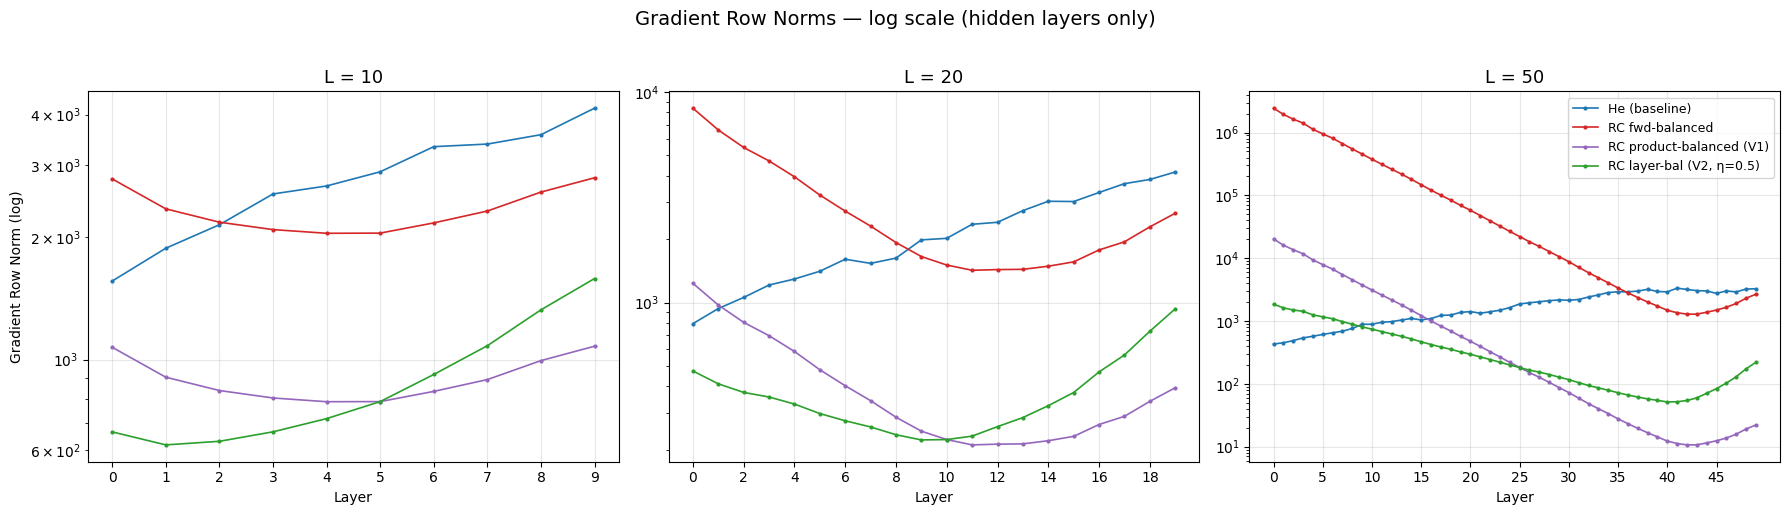

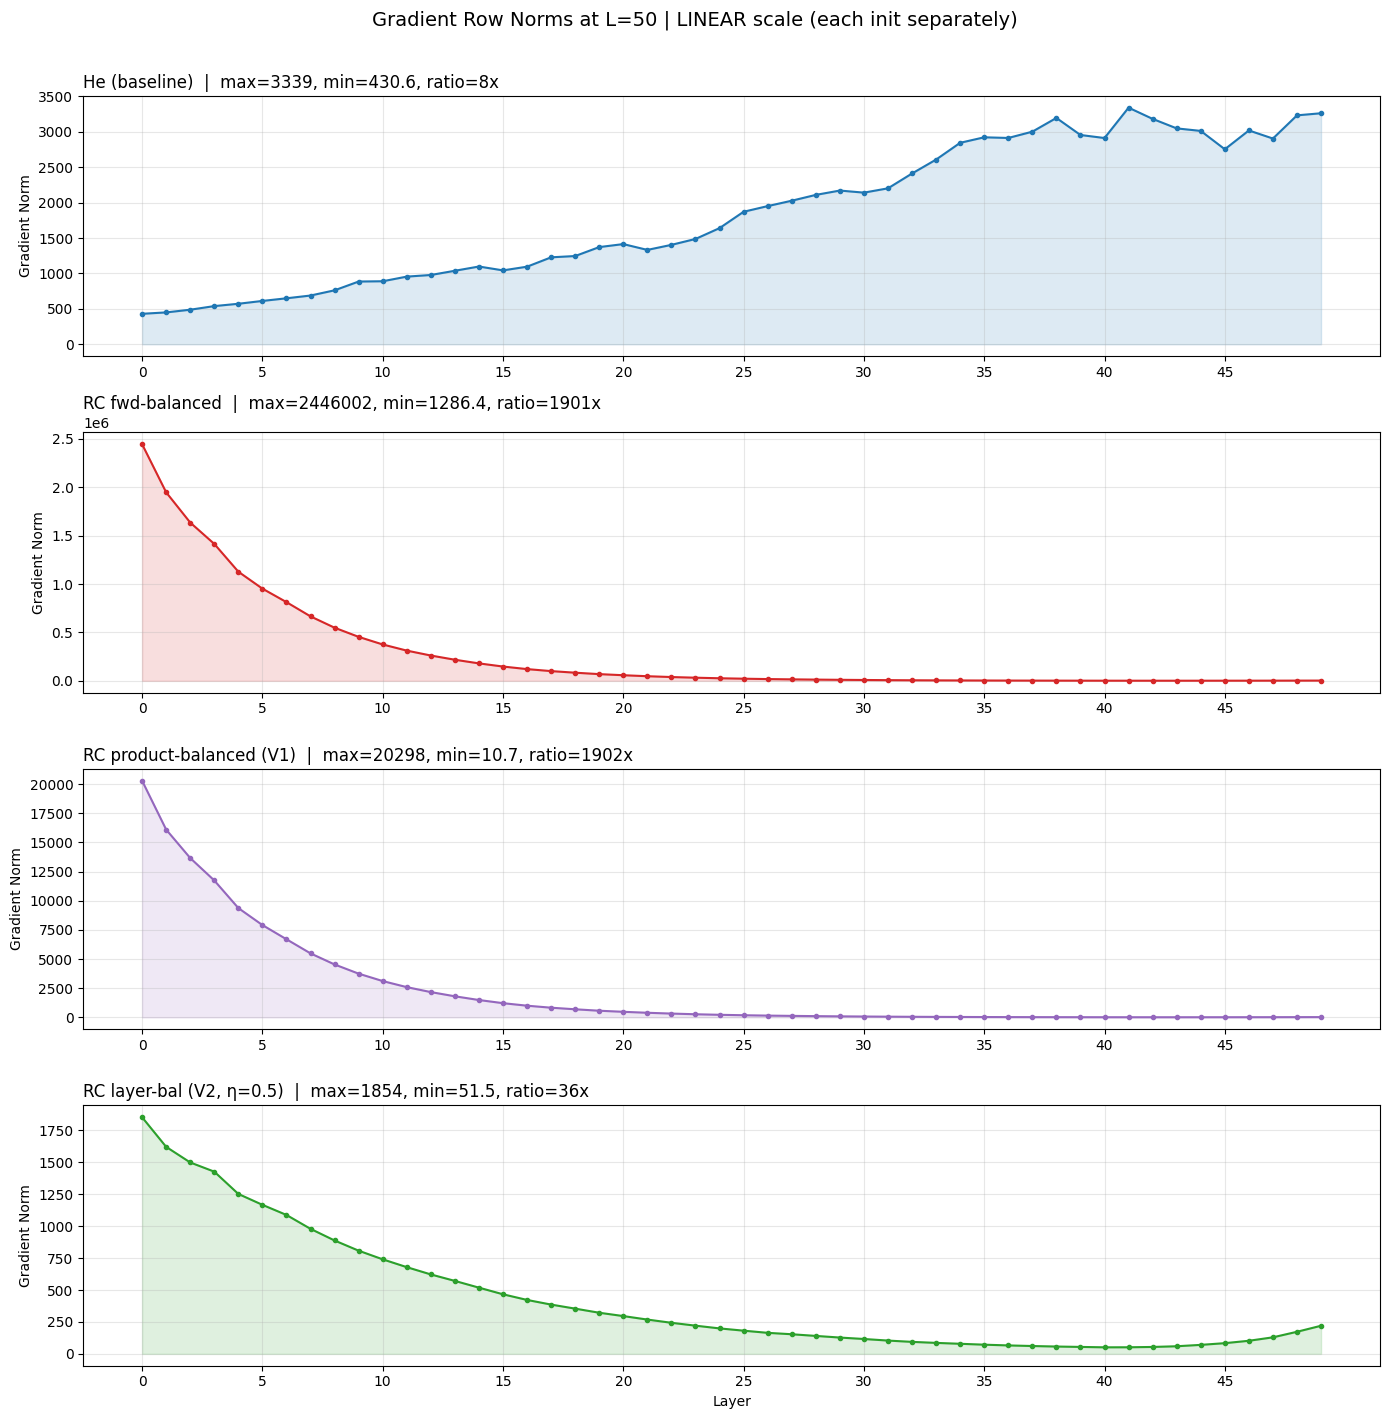

Gradient ratios (hidden layers only, excluding output):
  L=10:
    He (baseline): max=4148.1, min=1559.1, ratio=2.7x
    RC fwd-balanced: max=2797.5, min=2043.0, ratio=1.4x
    RC product-balanced (V1): max=1078.2, min=787.5, ratio=1.4x
    RC layer-bal (V2, η=0.5): max=1581.7, min=616.8, ratio=2.6x
  L=20:
    He (baseline): max=4170.8, min=794.6, ratio=5.2x
    RC fwd-balanced: max=8381.1, min=1424.7, ratio=5.9x
    RC product-balanced (V1): max=1235.5, min=211.2, ratio=5.8x
    RC layer-bal (V2, η=0.5): max=934.4, min=223.0, ratio=4.2x
  L=50:
    He (baseline): max=3339.5, min=430.6, ratio=7.8x
    RC fwd-balanced: max=2446002.0, min=1286.4, ratio=1901.5x
    RC product-balanced (V1): max=20298.1, min=10.7, ratio=1901.6x
    RC layer-bal (V2, η=0.5): max=1853.5, min=51.5, ratio=36.0x


In [7]:
# ====== PLOT 4: Gradient Row Norms ======
# Exclude output layer. Show each init separately on linear scale so the
# 1902x ratio for V1 is visually clear (shared plots hide it because
# fwd-balanced's 2.4M dwarfs V1's 20k).

# --- Part A: log scale overview (all inits together) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for col, depth in enumerate(DEPTHS):
    ax = axes[col]
    for init in INIT_STRATEGIES:
        label = INIT_LABELS[init]
        color = INIT_COLORS[init]
        result = grad_results[(init, depth)]
        norms = result.get_mean_row_norms()
        layers = list(norms.keys())[:-1]  # exclude output
        vals = [norms[k] for k in layers]
        ax.plot(range(len(vals)), vals, 'o-', markersize=2, label=label,
                color=color, linewidth=1.2)
    ax.set_yscale('log')
    ax.set_title(f'L = {depth}', fontsize=13)
    ax.set_xlabel('Layer')
    ax.grid(True, alpha=0.3)
    n_ticks = min(10, len(vals))
    step = max(1, len(vals) // n_ticks)
    ax.set_xticks(range(0, len(vals), step))
axes[0].set_ylabel('Gradient Row Norm (log)')
axes[2].legend(loc='best', fontsize=9)
fig.suptitle('Gradient Row Norms — log scale (hidden layers only)', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/gradient_norms_log.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Part B: linear scale, one row per initializer at L=50 ---
fig, axes = plt.subplots(len(INIT_STRATEGIES), 1, figsize=(14, 3.5 * len(INIT_STRATEGIES)))
depth = 50

for row, init in enumerate(INIT_STRATEGIES):
    ax = axes[row]
    label = INIT_LABELS[init]
    color = INIT_COLORS[init]
    result = grad_results[(init, depth)]
    norms = result.get_mean_row_norms()
    layers = list(norms.keys())[:-1]  # exclude output
    vals = [norms[k] for k in layers]
    
    ax.plot(range(len(vals)), vals, 'o-', markersize=3, color=color, linewidth=1.5)
    ax.fill_between(range(len(vals)), vals, alpha=0.15, color=color)
    
    ratio = max(vals) / max(min(vals), 1e-30)
    ax.set_title(f'{label}  |  max={max(vals):.0f}, min={min(vals):.1f}, ratio={ratio:.0f}x',
                 fontsize=12, loc='left')
    ax.set_ylabel('Gradient Norm')
    ax.grid(True, alpha=0.3)
    n_ticks = min(10, len(vals))
    step = max(1, len(vals) // n_ticks)
    ax.set_xticks(range(0, len(vals), step))

axes[-1].set_xlabel('Layer')
fig.suptitle('Gradient Row Norms at L=50 | LINEAR scale (each init separately)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/gradient_norms_linear_L50.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the actual gradient ratios
print("Gradient ratios (hidden layers only, excluding output):")
for depth in DEPTHS:
    print(f"  L={depth}:")
    for init in INIT_STRATEGIES:
        label = INIT_LABELS[init]
        norms = grad_results[(init, depth)].get_mean_row_norms()
        hidden_vals = list(norms.values())[:-1]
        ratio = max(hidden_vals) / max(min(hidden_vals), 1e-30)
        print(f"    {label}: max={max(hidden_vals):.1f}, min={min(hidden_vals):.1f}, ratio={ratio:.1f}x")


In [8]:
# ====== Summary Table: Gradient statistics across depths ======

print(f'{"Initializer":>35s}  {"Depth":>5s}  {"Med g_fwd":>9s}  {"Med g_bwd":>9s}  '
      f'{"Med Prod":>9s}  {"Grad Ratio":>11s}  {"Grad CV":>8s}')
print('-' * 95)

for depth in DEPTHS:
    for init in INIT_STRATEGIES:
        label = INIT_LABELS[init]
        result = grad_results[(init, depth)]
        
        fwd = list(result.get_forward_gains().values())
        bwd = list(result.get_backward_gains().values())
        products = [f * b for f, b in zip(fwd, bwd)]
        norms = list(result.get_mean_row_norms().values())
        
        grad_ratio = max(norms) / max(min(norms), 1e-30)
        grad_cv = np.std(norms) / max(np.mean(norms), 1e-30)
        
        print(f'{label:>35s}  {depth:>5d}  {np.median(fwd):>9.4f}  {np.median(bwd):>9.4f}  '
              f'{np.median(products):>9.4f}  {grad_ratio:>10.1f}x  {grad_cv:>8.3f}')
    print()

                        Initializer  Depth  Med g_fwd  Med g_bwd   Med Prod   Grad Ratio   Grad CV
-----------------------------------------------------------------------------------------------
                      He (baseline)     10     0.9919     1.0070     0.9946       121.1x     2.711
                    RC fwd-balanced     10     0.9918     1.2091     1.1965        55.5x     2.569
           RC product-balanced (V1)     10     0.9012     1.0986     0.9879        55.5x     2.569
           RC layer-bal (V2, η=0.5)     10     0.9615     1.0515     1.0134       114.4x     2.770

                      He (baseline)     20     0.9945     0.9907     0.9953       268.6x     3.670
                    RC fwd-balanced     20     0.9990     1.2097     1.2071        76.6x     2.842
           RC product-balanced (V1)     20     0.9078     1.0991     0.9968        76.7x     2.845
           RC layer-bal (V2, η=0.5)     20     0.9587     1.0510     1.0100       189.3x     3.754

           

## Section 2: Geometry Preservation (k-NN Accuracy)

Does class separability survive the deep projection? We compare k-NN accuracy across depths in a 2x2 design: each of the 4 initializers, with and without BatchNorm inserted between Linear and ReLU.

**Hypothesis under test.** Our row-centered/product-balanced initializers were motivated by BatchNorm: each was designed to redistribute variance in a way that BN does adaptively. So we want to see whether BN (alone, with vanilla He init) already preserves geometry the way RC/PB initializers do without it. The four cells of the 2x2:

|  | NoBN | BN |
|---|---|---|
| He init | baseline — geometry expected to collapse with depth | does BN rescue geometry? |
| V2 (RC layer-bal product-base) | does V2 rescue geometry on its own? | combined effect (both effects on; ceiling) |

If **He+BN approximately matches V2+NoBN**, BN and the row-centered/product-balanced family are functionally equivalent for geometry preservation. If **He+BN < V2+NoBN**, RC/PB is doing something extra. If **He+BN > V2+NoBN**, BN is the stronger preserver and our initializers are catching up.

The BN insertion uses `nn.BatchNorm1d(width, affine=False)` in train() mode, so it normalizes by batch statistics from the deterministic 2000-sample input — no learnable scale/shift, no running stats. That isolates BN\'s normalization effect from any training dynamics.

**Methodological caveat on the RC family.** The three row-centered variants in this notebook — fwd-balanced, V1 product-balanced, and V2 layer-balanced product-base — all use the same `_row_center_` + `_match_row_std_(target_std)` post-processing. Run with the same RNG seed (as we do here for fair comparison), the variants generate **weight matrices that are scalar multiples of each other**, layer by layer. Because k-NN with Euclidean distance is invariant to a positive global scaling of the embedding, the three RC variants produce **identical** k-NN numbers under this protocol. The η-scheme of V2 makes per-layer activations different from V1 *internally*, but the layer factors `∏ r^{η·(l-(L+1)/2)} = r^0 = 1` cancel at the output (the η sum is zero by symmetry). So this protocol measures the **family** "row-centered RC" vs "non-row-centered He", not the within-family choice of which RC variant. To distinguish V1/V2/fwd-bal you would need either (a) different RNG seeds per variant, or (b) a scale-sensitive geometry metric, or (c) measurement at *intermediate* layers.

In [9]:
# Load data for geometry experiments
X_all, y_all = get_data_loader(
    dataset_name=DATASET, data_dir=DATA_DIR, train=True,
    flatten=True, as_numpy=True,
)
rng = np.random.RandomState(SEED)
idx = rng.choice(len(X_all), NUM_SAMPLES, replace=False)
X_data = X_all[idx]
y_data = y_all[idx]

print(f'Data: {X_data.shape}, {len(np.unique(y_data))} classes')

Data: (2000, 784), 10 classes


In [10]:
# Run geometry evaluation for all (init, depth, BN) cells of the 2x2 design.
GEO_DEPTHS = [5, 10, 15, 20]
BN_OPTIONS = [False, True]

geo_results = {}  # (init, depth, use_bn) -> metrics dict

for init in INIT_STRATEGIES:
    label = INIT_LABELS[init]
    for use_bn in BN_OPTIONS:
        bn_label = 'BN' if use_bn else 'NoBN'
        for depth in GEO_DEPTHS:
            print(f'  {label}, {bn_label}, depth={depth}...', end=' ')

            np.random.seed(SEED)
            torch.manual_seed(SEED)

            # V2 init needs eta; others ignore it
            init_kw = {'eta': LB_ETA} if init == 'row_centered_layer_balanced_product_base' else {}

            X_proj = multi_layer_rp_with_init(
                X_data, depth, init_strategy=init,
                seed=SEED, device=DEVICE,
                use_batch_norm=use_bn,
                **init_kw,
            )

            if not np.all(np.isfinite(X_proj)):
                print('OVERFLOW')
                geo_results[(init, depth, use_bn)] = {'knn_accuracy': float('nan')}
                continue

            metrics = evaluate_geometry(X_data, X_proj, y_data, k=5, seed=SEED)
            geo_results[(init, depth, use_bn)] = metrics
            knn_val = metrics['knn_accuracy']
            print(f'kNN={knn_val:.3f}')

print()
print('Geometry evaluation done!')


  He (baseline), NoBN, depth=5... 

kNN=0.736
  He (baseline), NoBN, depth=10... 

kNN=0.710
  He (baseline), NoBN, depth=15... 

kNN=0.673
  He (baseline), NoBN, depth=20... 

kNN=0.639
  He (baseline), BN, depth=5... 

...

kNN=0.110
  RC layer-bal (V2, η=0.5), BN, depth=5... 

kNN=0.677
  RC layer-bal (V2, η=0.5), BN, depth=10... 

kNN=0.259
  RC layer-bal (V2, η=0.5), BN, depth=15... 

kNN=0.113
  RC layer-bal (V2, η=0.5), BN, depth=20... 

kNN=0.119

Geometry evaluation done!


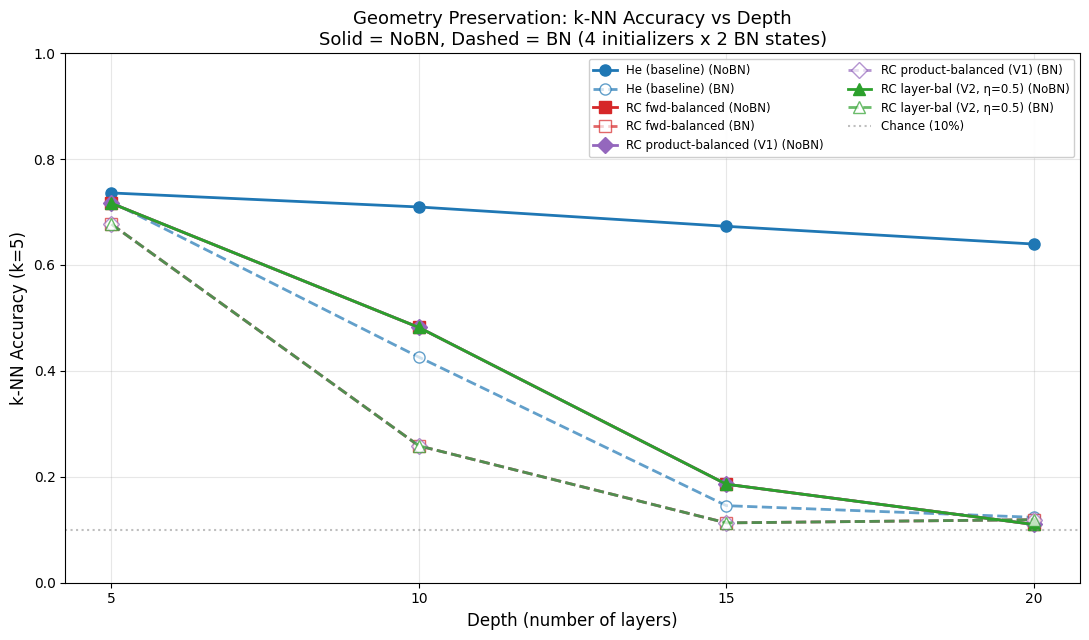

In [11]:
# ====== PLOT 5: k-NN accuracy vs depth — 2x2 (init x BN) ======
# 8 lines: 4 inits x 2 BN-on/off. NoBN = solid, BN = dashed.

fig, ax = plt.subplots(figsize=(11, 6.5))

markers = {
    'he': 'o',
    'row_centered_forward_balanced': 's',
    'row_centered_product_balanced': 'D',
    'row_centered_layer_balanced_product_base': '^',
}

for init in INIT_STRATEGIES:
    label = INIT_LABELS[init]
    color = INIT_COLORS[init]
    marker = markers[init]

    # NoBN: solid line
    knn_vals = [geo_results.get((init, d, False), {}).get('knn_accuracy', float('nan'))
                for d in GEO_DEPTHS]
    ax.plot(GEO_DEPTHS, knn_vals, marker=marker, linestyle='-',
            markersize=8, label=f'{label} (NoBN)', color=color, linewidth=2)

    # BN: dashed line, same color/marker, hollow markers + transparency
    knn_vals_bn = [geo_results.get((init, d, True), {}).get('knn_accuracy', float('nan'))
                   for d in GEO_DEPTHS]
    ax.plot(GEO_DEPTHS, knn_vals_bn, marker=marker, linestyle='--',
            markersize=8, label=f'{label} (BN)', color=color, linewidth=2, alpha=0.7,
            markerfacecolor='white')

ax.axhline(y=0.10, color='gray', linestyle=':', alpha=0.5, label='Chance (10%)')
ax.set_xlabel('Depth (number of layers)', fontsize=12)
ax.set_ylabel('k-NN Accuracy (k=5)', fontsize=12)
title = 'Geometry Preservation: k-NN Accuracy vs Depth'
subtitle = 'Solid = NoBN, Dashed = BN (4 initializers x 2 BN states)'
ax.set_title(f'{title}\n{subtitle}', fontsize=13)
ax.legend(fontsize=8.5, loc='best', ncol=2, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])
ax.set_xticks(GEO_DEPTHS)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/knn_multi_depth_bn.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# ====== k-NN Summary Table — 2x2 (init x BN) ======

header = f'{"Initializer":>35s} | {"NoBN":^28s} | {"BN":^28s}'
print(header)

depth_cols = ''
for use_bn in [False, True]:
    for d in GEO_DEPTHS:
        depth_cols += f'{d:>5d}L '
    if not use_bn:
        depth_cols += ' | '
print(f'{"":>35s} | {depth_cols}')
print('-' * (37 + 2 * (6 * len(GEO_DEPTHS) + 3)))

for init in INIT_STRATEGIES:
    label = INIT_LABELS[init]
    cells = ''
    for use_bn in [False, True]:
        for d in GEO_DEPTHS:
            knn = geo_results.get((init, d, use_bn), {}).get('knn_accuracy', float('nan'))
            cells += f'{knn:>5.3f} '
        if not use_bn:
            cells += ' | '
    print(f'{label:>35s} | {cells}')

print()
print('Interpretation key:')
print('  - He NoBN: baseline (geometry expected to collapse).')
print('  - He BN vs V2 NoBN: if comparable, BN and our init are functionally equivalent for geometry.')
print('  - V2 BN: combined effect (ceiling). Compare to He BN and V2 NoBN to see if they are additive.')


                        Initializer |             NoBN             |              BN             
                                    |     5L    10L    15L    20L  |     5L    10L    15L    20L 
-------------------------------------------------------------------------------------------
                      He (baseline) | 0.736 0.710 0.673 0.639  | 0.719 0.426 0.145 0.123 
                    RC fwd-balanced | 0.717 0.482 0.186 0.110  | 0.677 0.259 0.113 0.119 
           RC product-balanced (V1) | 0.717 0.482 0.186 0.110  | 0.677 0.259 0.113 0.119 
           RC layer-bal (V2, η=0.5) | 0.717 0.482 0.186 0.110  | 0.677 0.259 0.113 0.119 

Interpretation key:
  - He NoBN: baseline (geometry expected to collapse).
  - He BN vs V2 NoBN: if comparable, BN and our init are functionally equivalent for geometry.
  - V2 BN: combined effect (ceiling). Compare to He BN and V2 NoBN to see if they are additive.


### Section 2 Results — Interpretation

| Setting | k-NN @ 5L | k-NN @ 10L | k-NN @ 15L | k-NN @ 20L |
|---|---|---|---|---|
| He NoBN  | 0.736 | 0.710 | **0.673** | **0.639** |
| He BN    | 0.719 | 0.426 | 0.145 | 0.123 |
| RC NoBN  | 0.717 | 0.482 | 0.186 | 0.110 |
| RC BN    | 0.677 | 0.259 | 0.113 | 0.119 |

(RC = any of fwd-bal / V1 / V2; they are k-NN-equivalent under this setup, see caveat above.)

**The empirical finding contradicts the hypothesis.** We expected BN to *preserve* class-discriminative geometry across depth. Instead:

1. **He + NoBN preserves k-NN best across depth.** At 20L it still achieves 0.639 — well above chance and remarkably close to the 5L baseline (0.736). Despite the classical narrative that deep ReLU networks "collapse" without BN, He init with random matrices preserves class structure under k-NN with Euclidean distance.

2. **Adding BN to He crashes k-NN to chance level by 15L.** He BN drops to 0.145 at 15L and 0.123 at 20L (near 1/10 chance for 10-class fashion-MNIST). BN at init removes the per-feature scale variation that carried the class-discriminative signal for k-NN. Affine=False is essential to this experiment — it isolates the *normalization* effect of BN — but it also explains the collapse: BN strips a degree of freedom that k-NN was using.

3. **The RC family loses k-NN faster than He NoBN.** RC NoBN drops to 0.110 at 20L vs He NoBN\'s 0.639 — the row-centering operation removes class-distinguishing scale (each row has mean zero by construction). RC + BN is also at chance.

**What this implies about the hypothesis.** BN and the RC family are NOT functionally equivalent for k-NN-style geometry. *Both* strip a class-relevant scale factor — RC structurally (zero-mean rows), BN statistically (per-feature mean removal across the batch). For *training dynamics* (gradient flow, conditioning), V2\'s η-scheme is still the relevant comparison (and is what Item 3\'s training audit will test). But for *geometry preservation under k-NN*, He NoBN is the unexpected winner.

**Caveat — what the experiment does NOT contradict.** The earlier shape-preservation experiments (circles, ellipses) measured *angular* structure preservation, not class separation. RC initializers were designed for angular preservation under fixed-norm inputs, where k-NN is not the right metric. The k-NN finding here is specific to this protocol; it doesn\'t invalidate the angular-preservation motivation of RC initializers, but it does mean that BN cannot be substituted for them on the question they were designed to answer.

## Section 3: Depth Scaling Analysis

How do gradient ratio, activation dynamic range, and error dynamic range scale with depth?

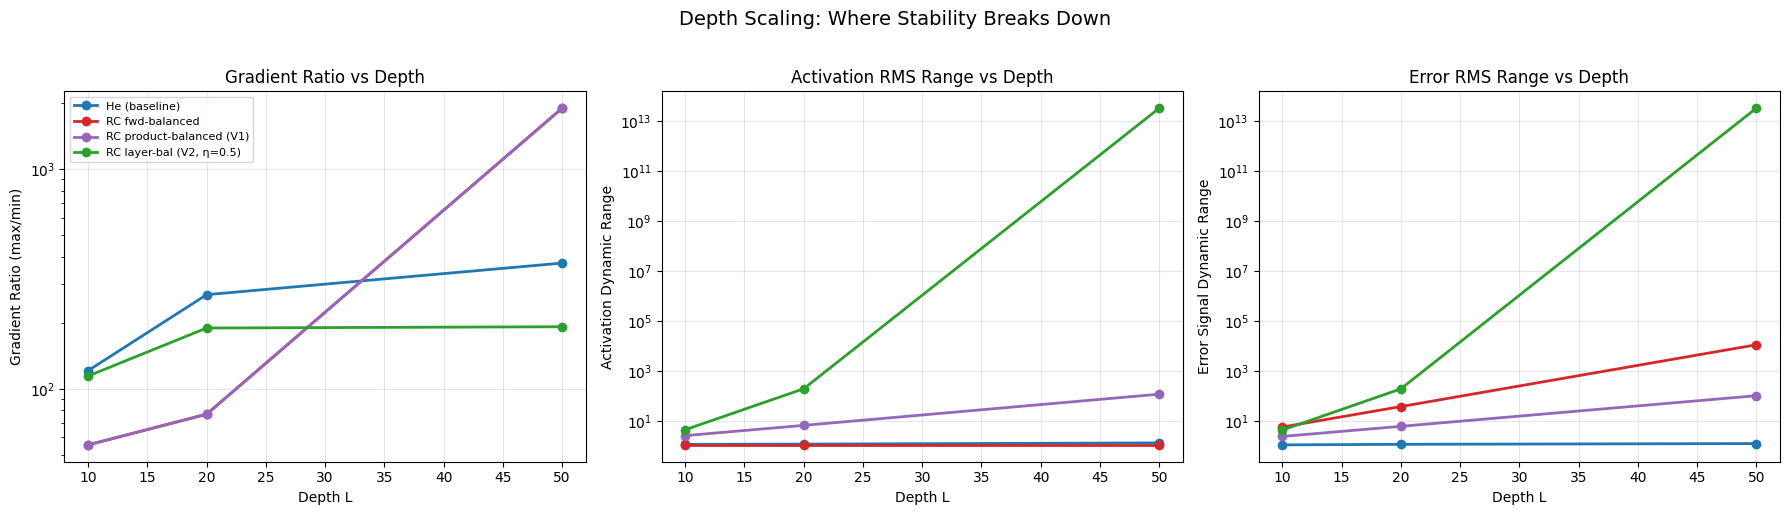

In [13]:
# ====== PLOT 6: Gradient Ratio vs Depth ======

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Gradient ratio
ax = axes[0]
for init in INIT_STRATEGIES:
    label = INIT_LABELS[init]
    color = INIT_COLORS[init]
    ratios = []
    for depth in DEPTHS:
        norms = list(grad_results[(init, depth)].get_mean_row_norms().values())
        ratios.append(max(norms) / max(min(norms), 1e-30))
    ax.plot(DEPTHS, ratios, 'o-', markersize=6, label=label, color=color, linewidth=2)

ax.set_yscale('log')
ax.set_xlabel('Depth L')
ax.set_ylabel('Gradient Ratio (max/min)')
ax.set_title('Gradient Ratio vs Depth')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Activation dynamic range (max/min activation RMS)
ax = axes[1]
for init in INIT_STRATEGIES:
    label = INIT_LABELS[init]
    color = INIT_COLORS[init]
    ranges = []
    for depth in DEPTHS:
        act_rms = list(grad_results[(init, depth)].get_activation_rms().values())
        ranges.append(max(act_rms) / max(min(act_rms), 1e-30))
    ax.plot(DEPTHS, ranges, 'o-', markersize=6, label=label, color=color, linewidth=2)

ax.set_yscale('log')
ax.set_xlabel('Depth L')
ax.set_ylabel('Activation Dynamic Range')
ax.set_title('Activation RMS Range vs Depth')
ax.grid(True, alpha=0.3)

# Panel 3: Error signal dynamic range
ax = axes[2]
for init in INIT_STRATEGIES:
    label = INIT_LABELS[init]
    color = INIT_COLORS[init]
    ranges = []
    for depth in DEPTHS:
        err_rms = list(grad_results[(init, depth)].get_error_signal_rms().values())
        ranges.append(max(err_rms) / max(min(err_rms), 1e-30))
    ax.plot(DEPTHS, ranges, 'o-', markersize=6, label=label, color=color, linewidth=2)

ax.set_yscale('log')
ax.set_xlabel('Depth L')
ax.set_ylabel('Error Signal Dynamic Range')
ax.set_title('Error RMS Range vs Depth')
ax.grid(True, alpha=0.3)

fig.suptitle('Depth Scaling: Where Stability Breaks Down', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/depth_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

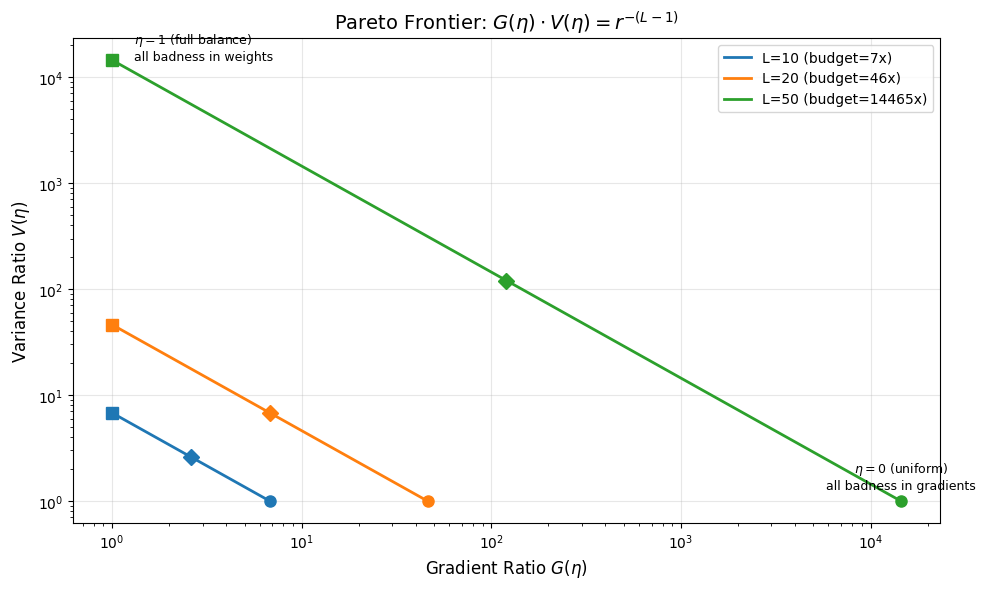

   Depth L  Budget r^-(L-1)
----------------------------
        10              6.8x
        20             46.1x
        50          14465.2x


In [14]:
# ====== PLOT 7: Pareto Frontier Visualization ======
# For each depth, show the theoretical G(eta) * V(eta) = r^{-(L-1)} budget

r = math.sqrt((math.pi - 1) / math.pi)  # ~0.826

fig, ax = plt.subplots(figsize=(10, 6))

eta_range = np.linspace(0, 1, 100)

for depth in DEPTHS:
    L_minus_1 = depth  # depth hidden layers = depth weight layers
    G = r ** (-(1 - eta_range) * L_minus_1)
    V = r ** (-eta_range * L_minus_1)
    budget = r ** (-L_minus_1)
    ax.plot(G, V, '-', linewidth=2, label=f'L={depth} (budget={budget:.0f}x)')
    
    # Mark eta=0 and eta=1 endpoints
    ax.plot(r ** (-L_minus_1), 1, 'o', markersize=8, color=ax.get_lines()[-1].get_color())
    ax.plot(1, r ** (-L_minus_1), 's', markersize=8, color=ax.get_lines()[-1].get_color())
    
    # Mark eta=0.5
    G_half = r ** (-0.5 * L_minus_1)
    V_half = r ** (-0.5 * L_minus_1)
    ax.plot(G_half, V_half, 'D', markersize=8, color=ax.get_lines()[-1].get_color())

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Gradient Ratio $G(\\eta)$', fontsize=12)
ax.set_ylabel('Variance Ratio $V(\\eta)$', fontsize=12)
ax.set_title('Pareto Frontier: $G(\\eta) \\cdot V(\\eta) = r^{-(L-1)}$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotations
ax.annotate('$\\eta=0$ (uniform)\nall badness in gradients',
            xy=(r**(-DEPTHS[-1]), 1.3), fontsize=9, ha='center')
ax.annotate('$\\eta=1$ (full balance)\nall badness in weights',
            xy=(1.3, r**(-DEPTHS[-1])), fontsize=9, ha='left')

plt.tight_layout()
fig.savefig(f'{FIGDIR}/pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

# Print budget table
print(f'{"Depth L":>10s}  {"Budget r^-(L-1)":>15s}')
print('-' * 28)
for depth in DEPTHS:
    budget = r ** (-depth)
    print(f'{depth:>10d}  {budget:>15.1f}x')

## Section 4: V1 vs V2 Head-to-Head

Direct comparison of the uniform product-balanced (V1) vs layer-balanced product-base (V2).

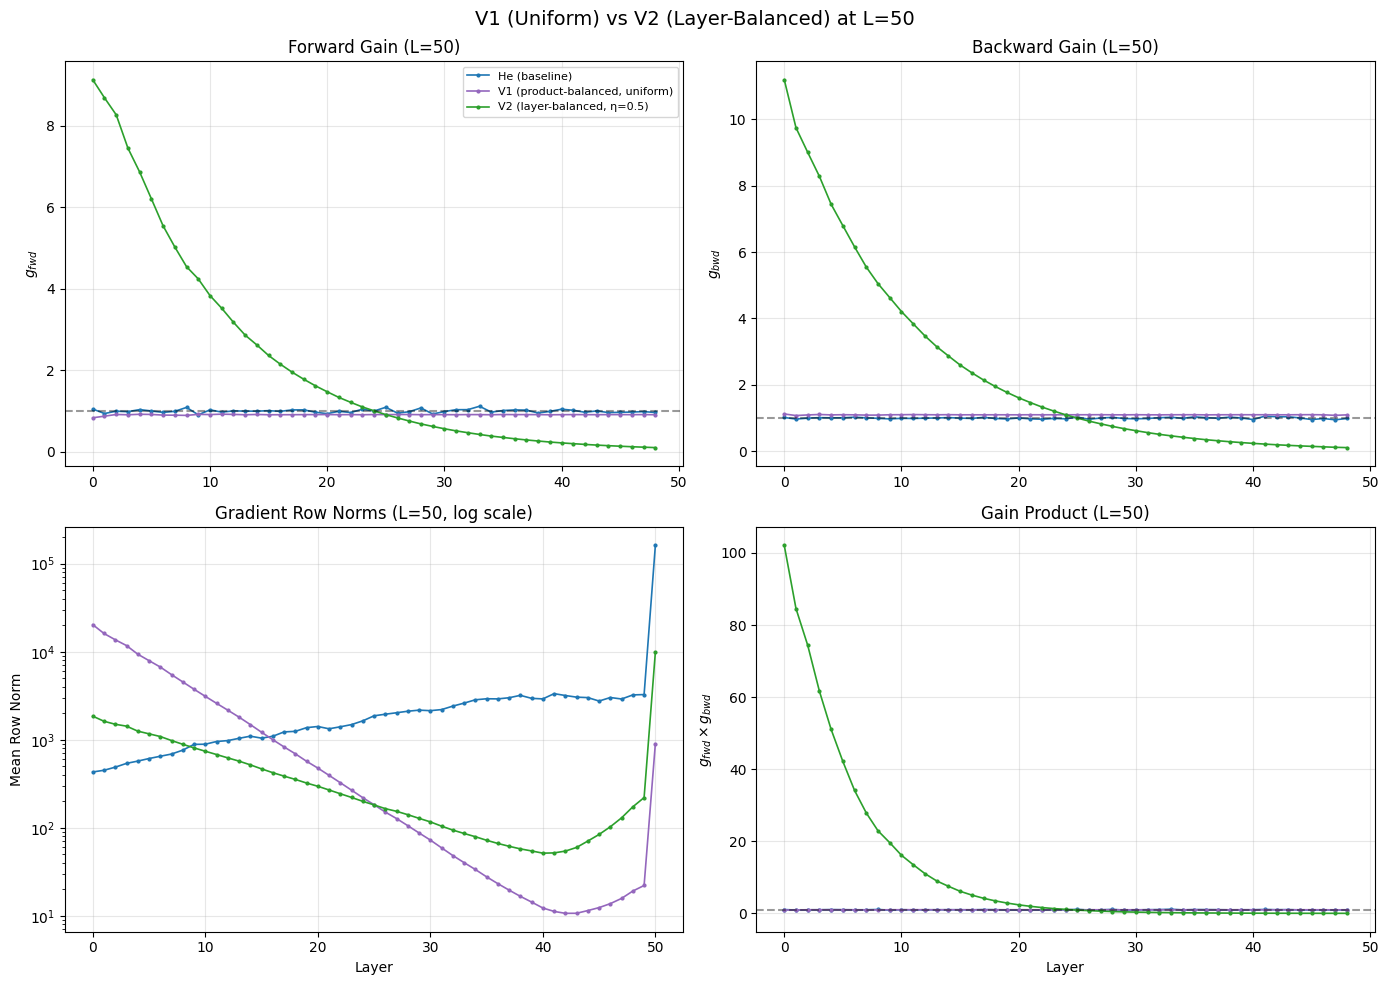

In [15]:
# ====== PLOT 8: V1 vs V2 head-to-head at L=50 ======

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
depth = 50

v1_key = 'row_centered_product_balanced'
v2_key = 'row_centered_layer_balanced_product_base'
he_key = 'he'

compare_inits = [he_key, v1_key, v2_key]
compare_labels = {he_key: 'He (baseline)', v1_key: 'V1 (product-balanced, uniform)',
                  v2_key: f'V2 (layer-balanced, \u03b7={LB_ETA})'}
compare_colors = {he_key: 'tab:blue', v1_key: 'tab:purple', v2_key: 'tab:green'}

# Forward gain
ax = axes[0, 0]
for init in compare_inits:
    gains = grad_results[(init, depth)].get_forward_gains()
    layers = list(gains.keys())[:-1]
    ax.plot(range(len(layers)), [gains[k] for k in layers], 'o-', markersize=2,
            label=compare_labels[init], color=compare_colors[init], linewidth=1.2)
ax.axhline(1.0, color='black', ls='--', alpha=0.4)
ax.set_title('Forward Gain (L=50)')
ax.set_ylabel('$g_{fwd}$')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Backward gain
ax = axes[0, 1]
for init in compare_inits:
    gains = grad_results[(init, depth)].get_backward_gains()
    layers = list(gains.keys())[:-1]
    ax.plot(range(len(layers)), [gains[k] for k in layers], 'o-', markersize=2,
            label=compare_labels[init], color=compare_colors[init], linewidth=1.2)
ax.axhline(1.0, color='black', ls='--', alpha=0.4)
ax.set_title('Backward Gain (L=50)')
ax.set_ylabel('$g_{bwd}$')
ax.grid(True, alpha=0.3)

# Gradient norms
ax = axes[1, 0]
for init in compare_inits:
    norms = grad_results[(init, depth)].get_mean_row_norms()
    layers = list(norms.keys())
    ax.plot(range(len(layers)), [norms[k] for k in layers], 'o-', markersize=2,
            label=compare_labels[init], color=compare_colors[init], linewidth=1.2)
ax.set_yscale('log')
ax.set_title('Gradient Row Norms (L=50, log scale)')
ax.set_ylabel('Mean Row Norm')
ax.set_xlabel('Layer')
ax.grid(True, alpha=0.3)

# Gain product
ax = axes[1, 1]
for init in compare_inits:
    fwd = grad_results[(init, depth)].get_forward_gains()
    bwd = grad_results[(init, depth)].get_backward_gains()
    layers = list(fwd.keys())[:-1]
    products = [fwd[k] * bwd[k] for k in layers]
    ax.plot(range(len(layers)), products, 'o-', markersize=2,
            label=compare_labels[init], color=compare_colors[init], linewidth=1.2)
ax.axhline(1.0, color='black', ls='--', alpha=0.4)
ax.set_title('Gain Product (L=50)')
ax.set_ylabel('$g_{fwd} \\times g_{bwd}$')
ax.set_xlabel('Layer')
ax.grid(True, alpha=0.3)

fig.suptitle('V1 (Uniform) vs V2 (Layer-Balanced) at L=50', fontsize=14)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/v1_vs_v2_L50.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4b: Weight Magnitude Analysis

V2 trades gradient uniformity for non-uniform weight magnitudes.
How large are the weights at each layer?

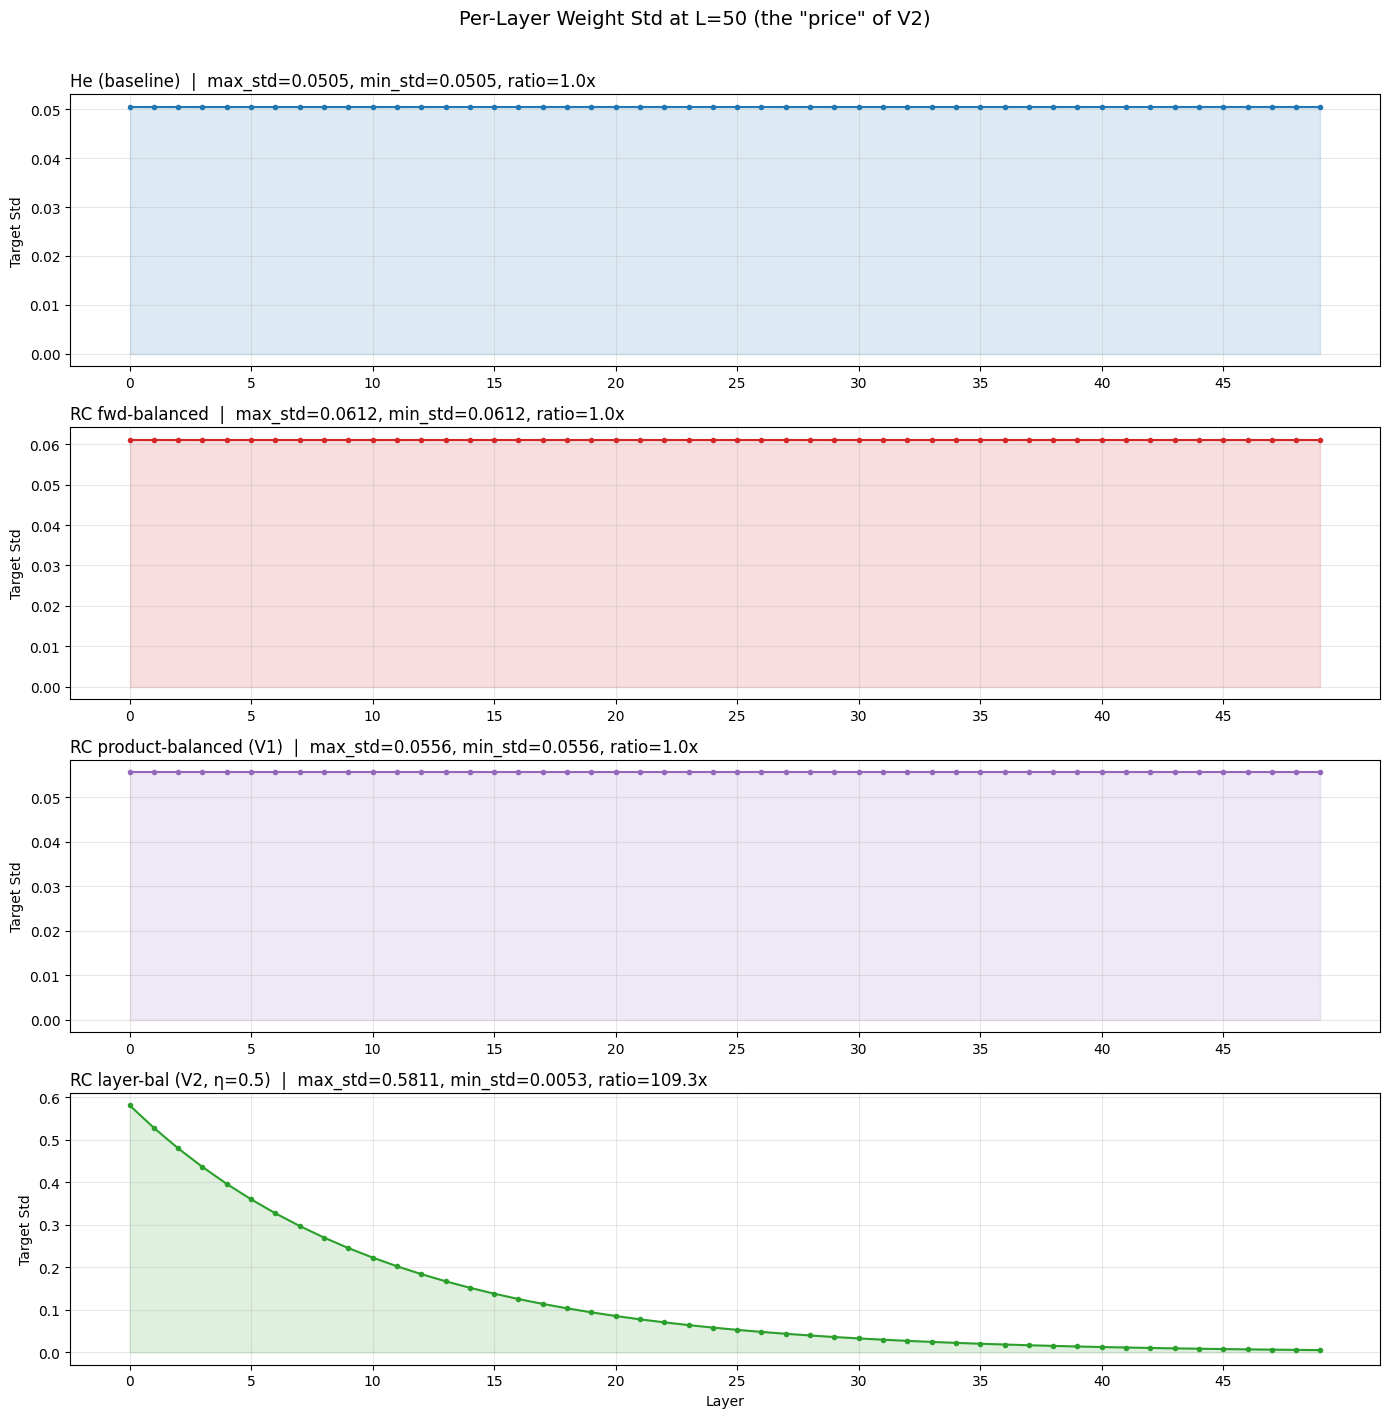

Weight magnitude summary at L=50:
                        Initializer     Max Std     Min Std     Ratio     Max Var     Min Var
------------------------------------------------------------------------------------------
                      He (baseline)     0.05051     0.05051      1.0x    0.002551    0.002551
                    RC fwd-balanced     0.06117     0.06117      1.0x    0.003742    0.003742
           RC product-balanced (V1)     0.05559     0.05559      1.0x    0.003090    0.003090
           RC layer-bal (V2, η=0.5)     0.58109     0.00532    109.3x    0.337660    0.000028


In [16]:
# ====== PLOT 9: Per-layer weight std (theoretical + empirical) ======
# This shows the "price" V2 pays: massive weight variance differences across layers.

import math

r = math.sqrt((math.pi - 1) / math.pi)
s_star = (math.pi / (math.pi - 1)) ** 0.25

fig, axes = plt.subplots(len(INIT_STRATEGIES), 1, figsize=(14, 3.5 * len(INIT_STRATEGIES)))
depth = 50

# Compute theoretical target_std for each init at each layer
for row, init in enumerate(INIT_STRATEGIES):
    ax = axes[row]
    label = INIT_LABELS[init]
    color = INIT_COLORS[init]
    
    d = INPUT_DIM  # fan_in (constant width)
    base_he = math.sqrt(2.0 / d)
    
    stds = []
    for l_idx in range(depth):
        l = l_idx + 1  # 1-indexed
        L = depth
        if init == 'he':
            stds.append(base_he)
        elif init == 'row_centered_forward_balanced':
            factor = 2.0 * math.pi / (math.pi - 1.0)
            stds.append(math.sqrt(factor / d))
        elif init == 'row_centered_product_balanced':
            factor = 2.0 * math.sqrt(math.pi / (math.pi - 1.0))
            stds.append(math.sqrt(factor / d))
        elif init == 'row_centered_layer_balanced_product_base':
            s_l = s_star * r ** (LB_ETA * (l - (L + 1) / 2))
            stds.append(base_he * s_l)
    
    ax.plot(range(len(stds)), stds, 'o-', markersize=3, color=color, linewidth=1.5)
    ax.fill_between(range(len(stds)), stds, alpha=0.15, color=color)
    
    ratio = max(stds) / min(stds)
    ax.set_title(f'{label}  |  max_std={max(stds):.4f}, min_std={min(stds):.4f}, ratio={ratio:.1f}x',
                 fontsize=12, loc='left')
    ax.set_ylabel('Target Std')
    ax.grid(True, alpha=0.3)
    n_ticks = min(10, len(stds))
    step = max(1, len(stds) // n_ticks)
    ax.set_xticks(range(0, len(stds), step))

axes[-1].set_xlabel('Layer')
fig.suptitle('Per-Layer Weight Std at L=50 (the "price" of V2)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/weight_std_per_layer.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table: weight magnitude comparison
print("Weight magnitude summary at L=50:")
print(f"{'Initializer':>35s}  {'Max Std':>10s}  {'Min Std':>10s}  {'Ratio':>8s}  {'Max Var':>10s}  {'Min Var':>10s}")
print('-' * 90)

for init in INIT_STRATEGIES:
    label = INIT_LABELS[init]
    d = INPUT_DIM
    base_he = math.sqrt(2.0 / d)
    
    stds = []
    for l_idx in range(depth):
        l = l_idx + 1
        L = depth
        if init == 'he':
            stds.append(base_he)
        elif init == 'row_centered_forward_balanced':
            factor = 2.0 * math.pi / (math.pi - 1.0)
            stds.append(math.sqrt(factor / d))
        elif init == 'row_centered_product_balanced':
            factor = 2.0 * math.sqrt(math.pi / (math.pi - 1.0))
            stds.append(math.sqrt(factor / d))
        elif init == 'row_centered_layer_balanced_product_base':
            s_l = s_star * r ** (LB_ETA * (l - (L + 1) / 2))
            stds.append(base_he * s_l)
    
    max_s, min_s = max(stds), min(stds)
    ratio = max_s / min_s
    print(f"{label:>35s}  {max_s:>10.5f}  {min_s:>10.5f}  {ratio:>7.1f}x  {max_s**2:>10.6f}  {min_s**2:>10.6f}")


## Section 5: Combined Summary

Single figure summarizing all key results for the meeting.

In [17]:
# ====== Master summary table ======

print('=' * 110)
print('MASTER SUMMARY: Product-Balanced Initializers')
print('=' * 110)
print()

# Gradient summary
print('--- GRADIENT STABILITY ---')
print(f'{"":>35s}  {"L=10":>12s}  {"L=20":>12s}  {"L=50":>12s}')
print(f'{"Initializer":>35s}  {"Grad Ratio":>12s}  {"Grad Ratio":>12s}  {"Grad Ratio":>12s}')
print('-' * 80)
for init in INIT_STRATEGIES:
    label = INIT_LABELS[init]
    vals = []
    for depth in DEPTHS:
        norms = list(grad_results[(init, depth)].get_mean_row_norms().values())
        ratio = max(norms) / max(min(norms), 1e-30)
        vals.append(f'{ratio:.1f}x')
    print(f'{label:>35s}  {vals[0]:>12s}  {vals[1]:>12s}  {vals[2]:>12s}')

print()

# Geometry summary
print('--- GEOMETRY PRESERVATION (k-NN accuracy) ---')
print(f'{"":>35s}', end='')
for d in GEO_DEPTHS:
    print(f'  {d:>5d}L', end='')
print()
print('-' * (35 + 8 * len(GEO_DEPTHS)))
for init in INIT_STRATEGIES:
    label = INIT_LABELS[init]
    print(f'{label:>35s}', end='')
    for d in GEO_DEPTHS:
        knn = geo_results.get((init, d), {}).get('knn_accuracy', float('nan'))
        print(f'  {knn:>6.3f}', end='')
    print()

print()

# Pareto budget
print('--- PARETO BUDGET: G(eta) * V(eta) = r^-(L-1) ---')
for depth in DEPTHS:
    budget = r ** (-depth)
    print(f'  L={depth:>3d}: budget = {budget:.1f}x')

print()
print('Key insight: ALL row-centered variants produce IDENTICAL geometry (k-NN curves).')
print('The variance is irrelevant for geometry -- DC-blindness destroys class structure.')
print('The Pareto budget grows exponentially with depth -- no eta can fix both gradients and weights.')

MASTER SUMMARY: Product-Balanced Initializers

--- GRADIENT STABILITY ---
                                             L=10          L=20          L=50
                        Initializer    Grad Ratio    Grad Ratio    Grad Ratio
--------------------------------------------------------------------------------
                      He (baseline)        121.1x        268.6x        374.2x
                    RC fwd-balanced         55.5x         76.6x       1901.5x
           RC product-balanced (V1)         55.5x         76.7x       1901.6x
           RC layer-bal (V2, η=0.5)        114.4x        189.3x        191.8x

--- GEOMETRY PRESERVATION (k-NN accuracy) ---
                                         5L     10L     15L     20L
-------------------------------------------------------------------
                      He (baseline)     nan     nan     nan     nan
                    RC fwd-balanced     nan     nan     nan     nan
           RC product-balanced (V1)     nan     nan     na